# COVID-19 Clinical Trials - Exploratory Data Analysis

## 📌 Objective:
To explore and analyze clinical trial data related to COVID-19 using pandas and data visualization libraries. By extracting key insights from the dataset, clean it, and visualize trends related to trial phases, locations, demographics, and more.

**Data Source:** ClinicalTrials.gov
**Tools Used:** Python, Pandas, Matplotlib, Seaborn


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

In [4]:
df = pd.read_csv(r'C:\Python Project\COVID-19-complete-EDA-analysis-master\COVID clinical trials clean.csv', low_memory=False)

In [5]:
# Quick look at the data
df.head()

,Rank,NCT Number,Title,Acronym,Status,Study Results,Conditions,Interventions,Outcome Measures,Sponsor/Collaborators,...,Unnamed: 1287,Unnamed: 1288,Unnamed: 1289,Unnamed: 1290,Unnamed: 1291,Unnamed: 1292,Unnamed: 1293,Unnamed: 1294,Unnamed: 1295,Unnamed: 1296
0,1,NCT04785898,Diagnostic Performance of the ID Now™ COVID-19...,COVID-IDNow,"Active, not recruiting",No Results Available,Covid19,Diagnostic Test: ID Now™ COVID-19 Screening Test,Evaluate the diagnostic performance of the ID ...,Groupe Hospitalier Paris Saint Joseph,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,NCT04595136,Study to Evaluate the Efficacy of COVID19-0001...,COVID-19,Not yet recruiting,No Results Available,SARS-CoV-2 Infection,Drug: Drug COVID19-0001-USR|Drug: normal saline,Change on viral load results from baseline aft...,United Medical Specialties,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,NCT04395482,Lung CT Scan Analysis of SARS-CoV2 Induced Lun...,TAC-COVID19,Recruiting,No Results Available,covid19,Other: Lung CT scan analysis in COVID-19 patients,A qualitative analysis of parenchymal lung dam...,University of Milano Bicocca,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NCT04416061,The Role of a Private Hospital in Hong Kong Am...,COVID-19,"Active, not recruiting",No Results Available,COVID,Diagnostic Test: COVID 19 Diagnostic Test,Proportion of asymptomatic subjects|Proportion...,Hong Kong Sanatorium & Hospital,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NCT04395924,Maternal-foetal Transmission of SARS-Cov-2,TMF-COVID-19,Recruiting,No Results Available,Maternal Fetal Infection Transmission|COVID-19...,Diagnostic Test: Diagnosis of SARS-Cov2 by RT-...,COVID-19 by positive PCR in cord blood and / o...,Centre Hospitalier Régional d'Orléans|Centre d...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Shape and column info
print(f"Dataset shape: {df.shape}")
print("\nInfo:\n")
df.info()

Dataset shape: (5789, 1297)

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5789 entries, 0 to 5788
Columns: 1297 entries, Rank to Unnamed: 1296
dtypes: float64(1), object(1296)
memory usage: 57.3+ MB


In [5]:
# Dealing with the missing data
missing_percent = df.isnull().mean() * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

In [6]:
missing_percent

Unnamed: 1295         100.000000
Unnamed: 1280          99.982726
Unnamed: 1279          99.982726
Unnamed: 1278          99.982726
Unnamed: 1277          99.982726
                         ...    
Last Update Posted      0.051822
Rank                    0.051822
First Posted            0.051822
Funded Bys              0.051822
Study Type              0.051822
Length: 1297, dtype: float64

In [7]:
df.drop(columns=[col for col in ['Results First Posted', 'Study Documents'] if col in df.columns], inplace=True)

In [8]:
categorical_cols = df.select_dtypes(include='object').columns

In [28]:
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].astype(str).fillna(f"Missing: {col}")

In [14]:
# Filling numeric missing values using median

df['Enrollment'] = pd.to_numeric(df['Enrollment'], errors='coerce')
df['Enrollment'] = df['Enrollment'].fillna(df['Enrollment'].median())


In [15]:
# Checking if 'Locations' column exists

if 'Locations' in df.columns:
    df['Country'] = df['Locations'].apply(lambda x: str(x).split(',')[-1].strip())

In [31]:
date_cols = ['Start Date', 'Primary Completion Date', 'Completion Date']

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

In [20]:
if 'Start Date' in df.columns:
    df['Start Year'] = df['Start Date'].dt.year
    df['Start Month'] = df['Start Date'].dt.month

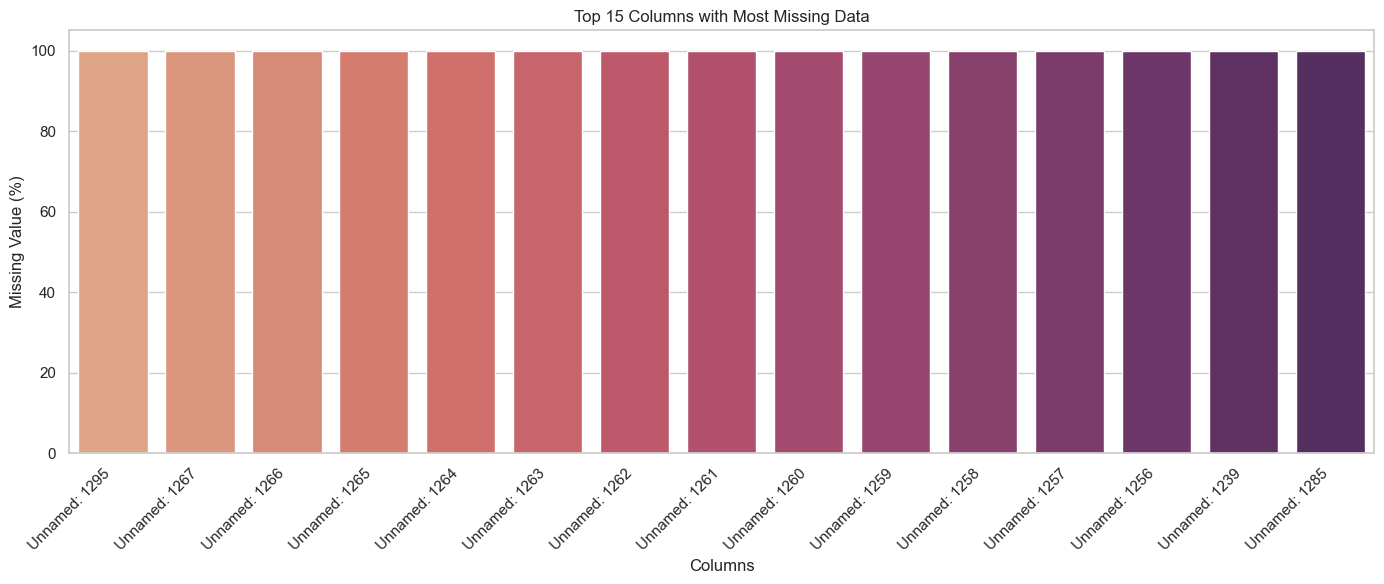

In [14]:
top_missing = missing_percent.sort_values(ascending=False).head(15)

plt.figure(figsize=(14, 6))
sns.barplot(
    x=top_missing.index,
    y=top_missing.values,
    hue=top_missing.index,
    dodge=False,
    palette=sns.color_palette("flare", n_colors=len(top_missing)),
    legend=False
)
plt.xticks(rotation=45, ha='right')
plt.title("Top 15 Columns with Most Missing Data")
plt.ylabel("Missing Value (%)")
plt.xlabel("Columns")
plt.tight_layout()
plt.show()


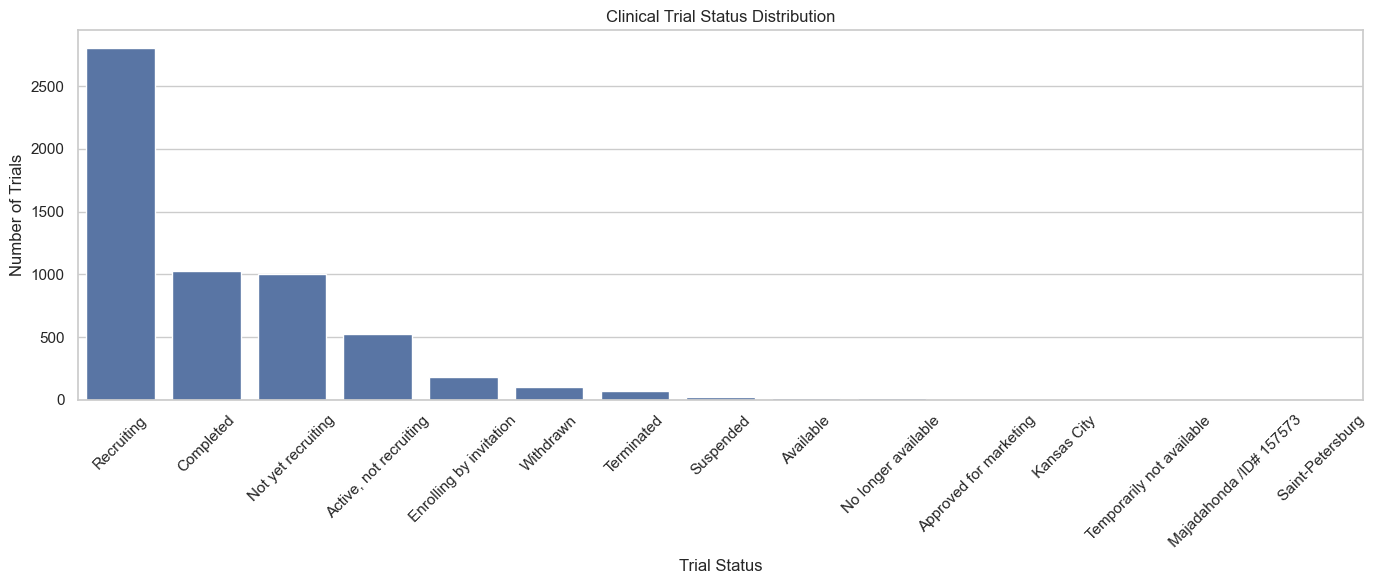

In [21]:
# Univariate Analysis

status_counts = df['Status'].value_counts()

sns.barplot(x=status_counts.index, y=status_counts.values)
plt.title('Clinical Trial Status Distribution')
plt.ylabel('Number of Trials')
plt.xlabel('Trial Status')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

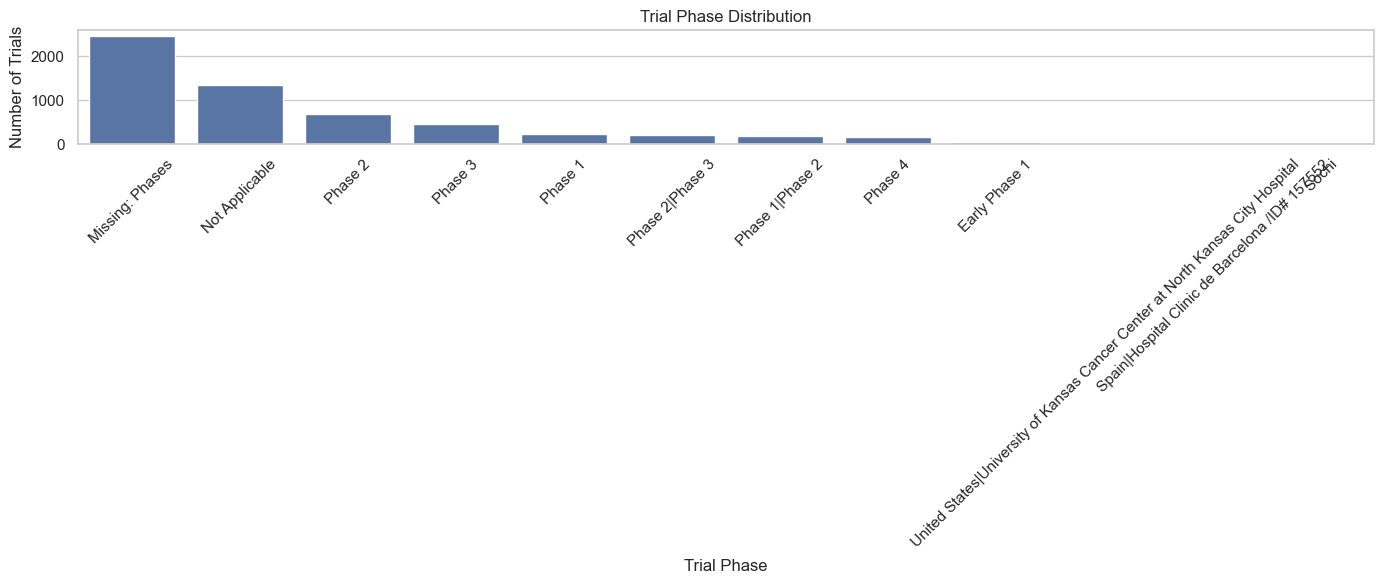

In [20]:
phase_counts = df['Phases'].value_counts()

sns.barplot(x=phase_counts.index, y=phase_counts.values)
plt.title('Trial Phase Distribution')
plt.ylabel('Number of Trials')
plt.xlabel('Trial Phase')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [22]:
def simplify_age_group(age):
    age = str(age)
    if 'Child' in age and 'Adult' in age and 'Older Adult' in age:
        return 'All Ages'
    elif 'Child' in age and 'Adult' in age:
        return 'Child + Adult'
    elif 'Child' in age:
        return 'Child'
    elif 'Older Adult' in age:
        return 'Senior'
    elif 'Adult' in age:
        return 'Adult'
    else:
        return 'Other'

df['Age Group'] = df['Age'].apply(simplify_age_group)


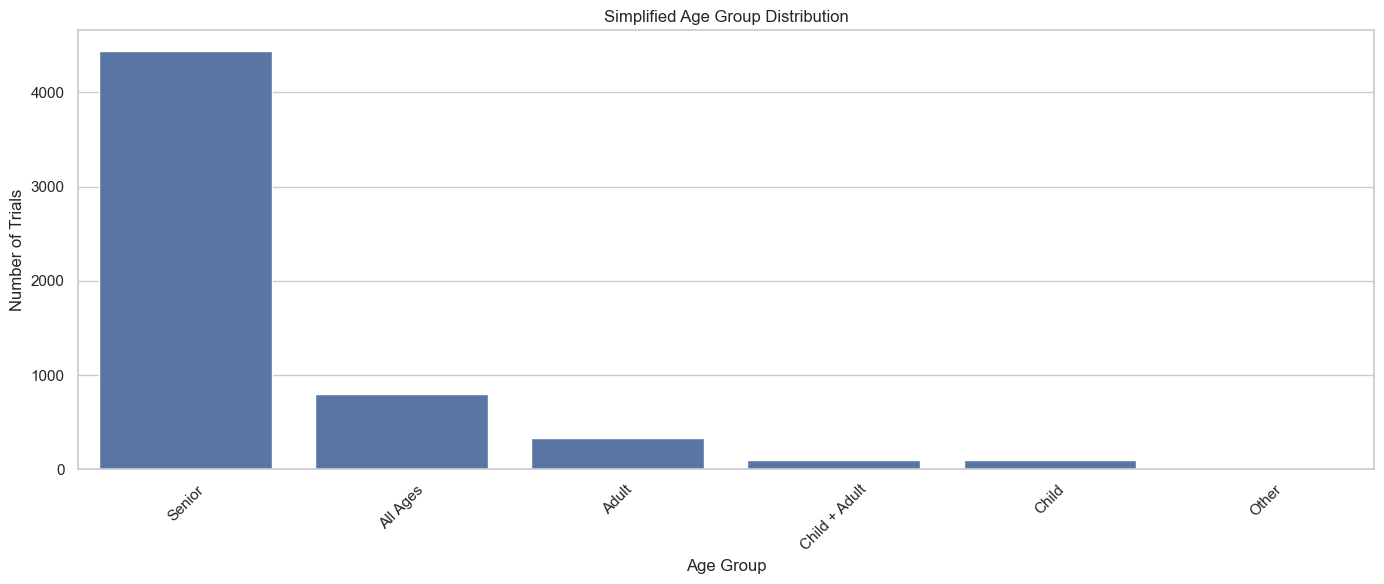

In [23]:
age_group_counts = df['Age Group'].value_counts()

sns.barplot(x=age_group_counts.index, y=age_group_counts.values)
plt.title('Simplified Age Group Distribution')
plt.ylabel('Number of Trials')
plt.xlabel('Age Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


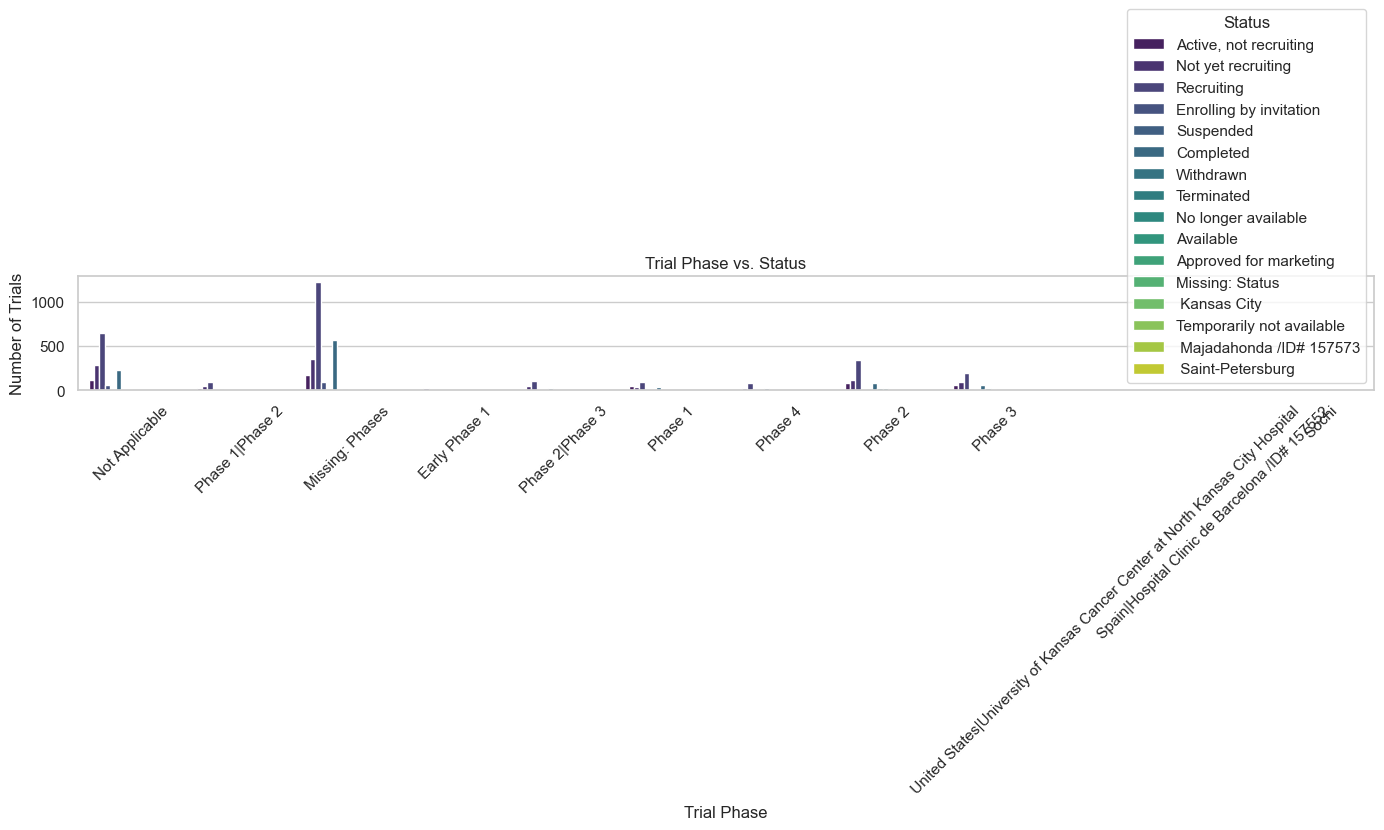

In [32]:
# Bivariate Analysis

sns.countplot(data=df, x='Phases', hue='Status', palette='viridis')
plt.title('Trial Phase vs. Status')
plt.xlabel('Trial Phase')
plt.ylabel('Number of Trials')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

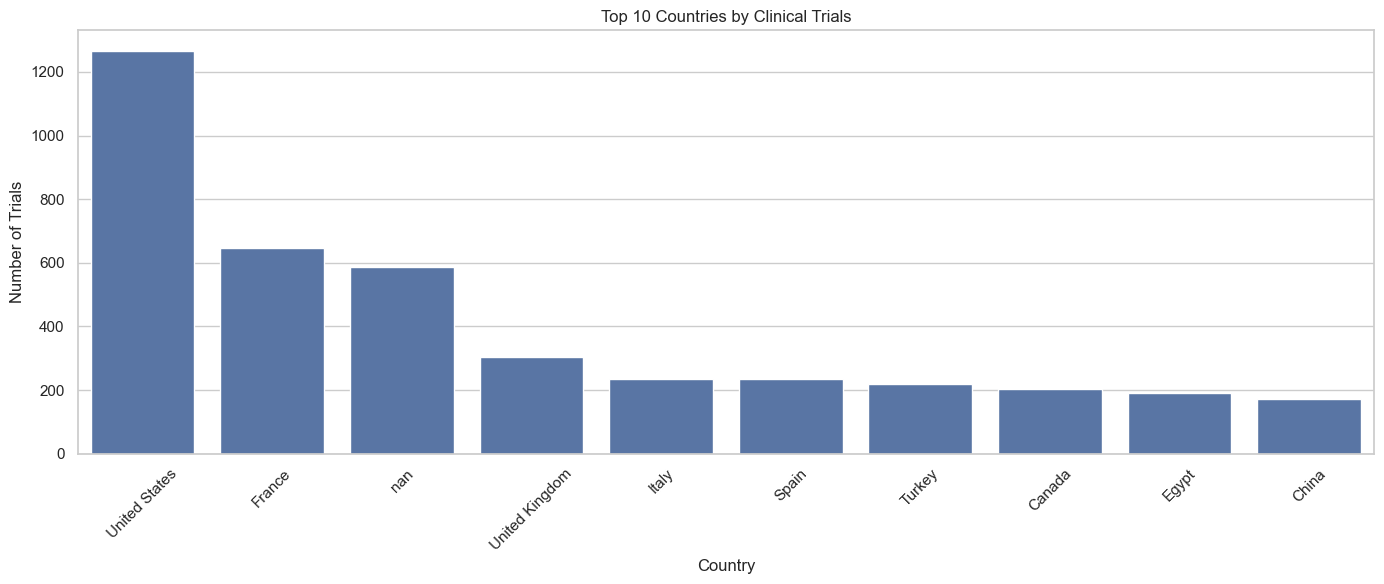

In [24]:
top_countries = df['Country'].value_counts().head(10)

sns.barplot(x=top_countries.index, y=top_countries.values)
plt.title('Top 10 Countries by Clinical Trials')
plt.ylabel('Number of Trials')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


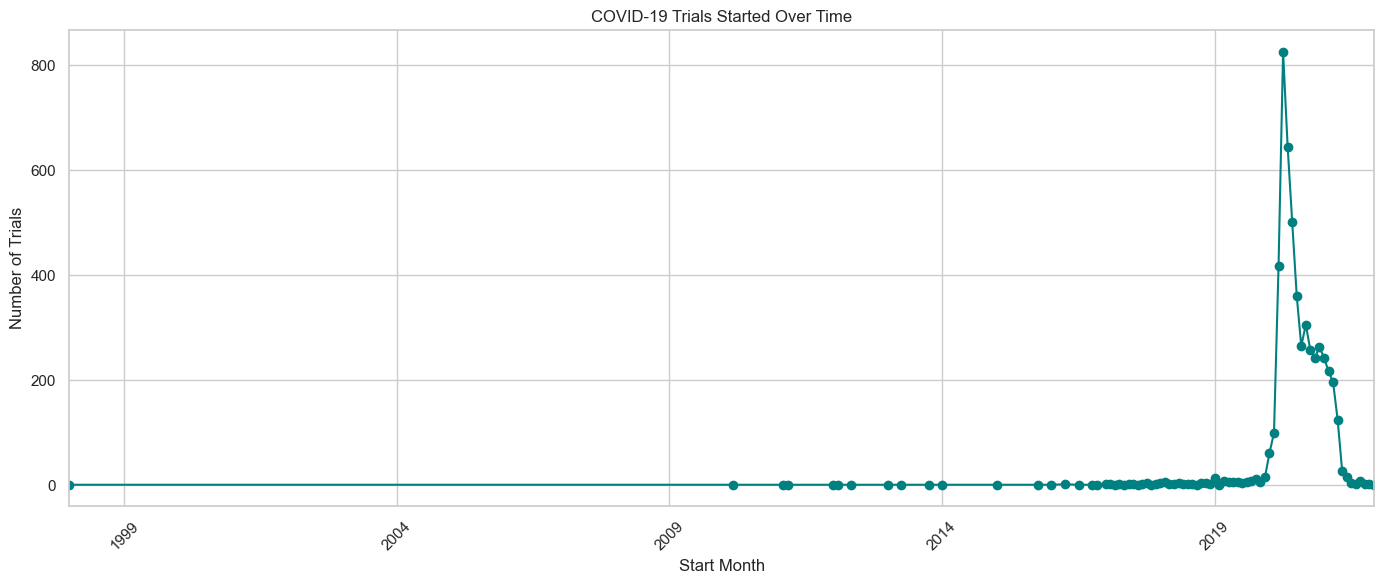

In [33]:
# Make sure Start Date is datetime
df['Start Date'] = pd.to_datetime(df['Start Date'], errors='coerce')

# Extract month-year
df['Start_Month'] = df['Start Date'].dt.to_period('M')

# Count trials by Start Month
trials_per_month = df['Start_Month'].value_counts().sort_index()

# Plot
trials_per_month.plot(kind='line', marker='o', color='teal')
plt.title("COVID-19 Trials Started Over Time")
plt.ylabel("Number of Trials")
plt.xlabel("Start Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df._consolidate_inplace()

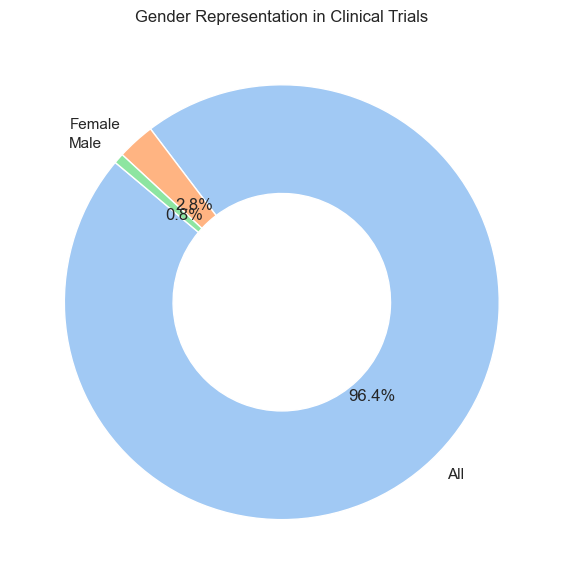

In [10]:
# Clean gender values first (optional, if messy)
df['Gender'] = df['Gender'].str.strip().str.title()

# Get value counts
gender_counts = df['Gender'].value_counts()

# Remove any weird/null/mixed values with very low count (optional)
gender_counts = gender_counts[gender_counts > 10]  # or any threshold you prefer

# Plot clean donut chart
plt.figure(figsize=(6, 6))
plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel'),
    wedgeprops={'width': 0.5}
)
plt.title('Gender Representation in Clinical Trials')
plt.tight_layout()
plt.show()

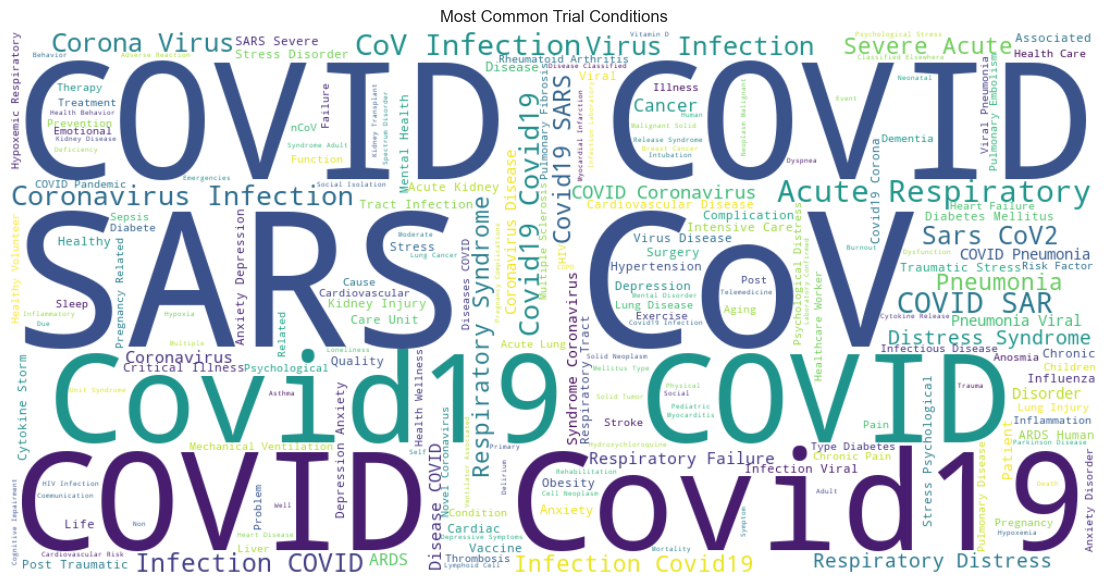

In [8]:
# Word cloud of most common conditions studied
from wordcloud import WordCloud

text = ' '.join(df['Conditions'].dropna())
wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Trial Conditions')
plt.tight_layout()
plt.show()

In [34]:
df.to_csv("covid_clinical_trials_cleaned.csv", index=False)

## 🔍 Insights
- Majority of trials were focused on adults and involved multiple phases
- The USA, France, and the UK had the highest number of COVID-related trials
- Significant spike in trials during early-mid 2020
- Most trials covered all genders; some were gender-specific
- Trial activity was globally diverse but centralized among top nations

## 📌 Conclusion

- Majority of trials started post-2020, peaking in early pandemic months.
- Most trials target adult and older adult age groups.
- Trial phases are spread out, with Phase 2 and Phase 3 being most common.
- The US, France, and UK lead in the number of COVID-19 clinical trials.
- Data cleaning involved handling complex age categories and missing values, with special attention to fragmented columns.

This analysis gives valuable insight into how different regions and age groups were considered in global COVID-19 clinical research.